In [1]:
import arviz as az
import matplotlib.pylab as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
az.style.use('arviz-grayscale')
from cycler import cycler
default_cycler = cycler(color=['#000000', '#6a6a6a', '#bebebe', '#2a2eec'])
plt.rc('axes', prop_cycle=default_cycler)
plt.rc('figure', dpi=300, figsize=(12, 4))

In [3]:
# Create sample data of 4 coin flips
np.random.seed(123)
trials = 4
theta_real = 0.35
data = pz.Binomial(n=1, p=theta_real).rvs(trials)
data

array([0, 0, 0, 1], dtype=int64)

In [4]:
with pm.Model() as our_first_model:
    θ = pm.Beta('θ', alpha=1.0, beta=1.0)
    y = pm.Bernoulli('y', p=θ, observed=data)
    idata = pm.sample(1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [θ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.


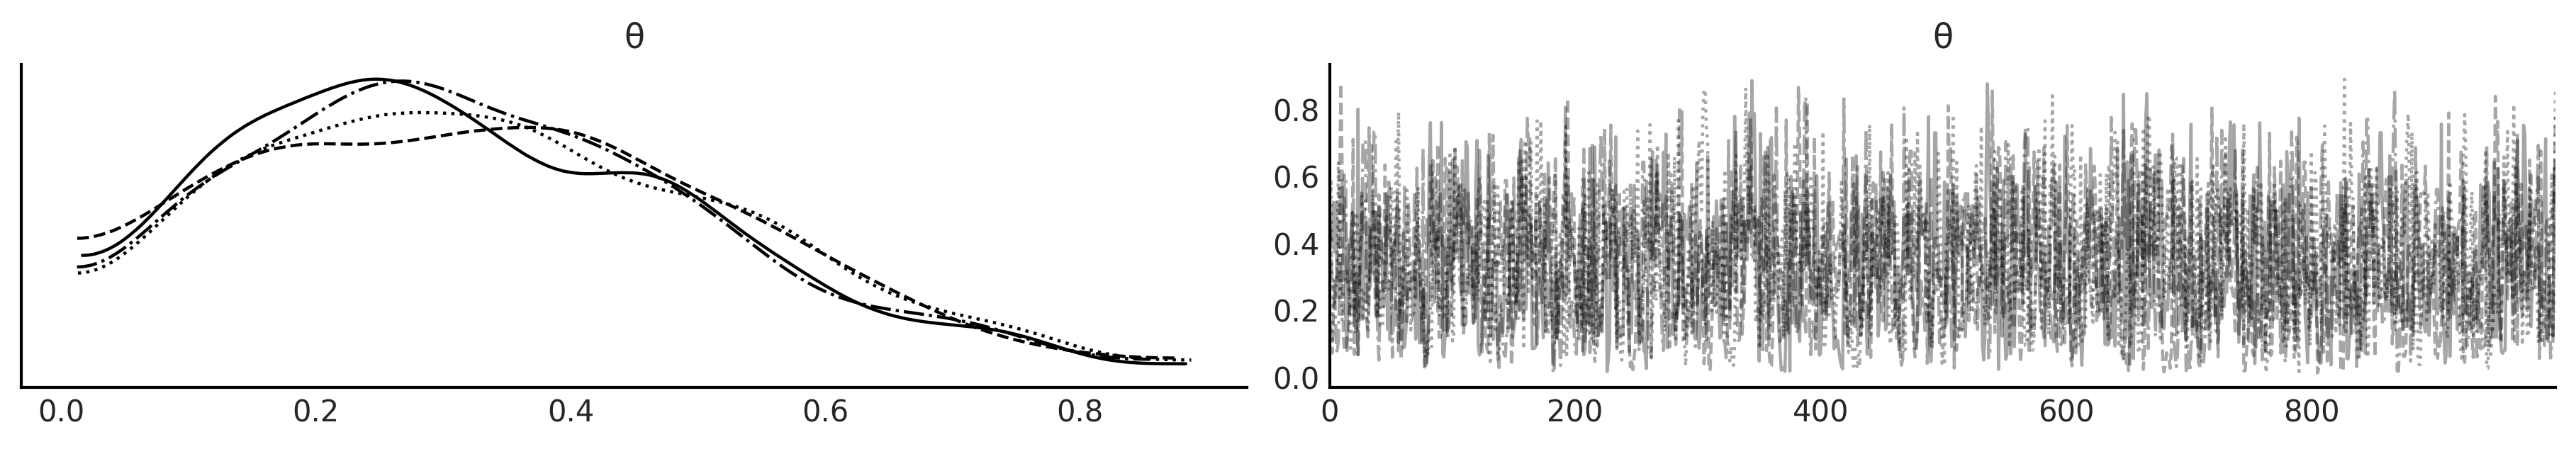

In [5]:
az.plot_trace(idata)
plt.savefig('fig/idata_trace.png')